In [2]:
# Import required packages for this project.
from pathlib import Path

import os
import calendar
import numpy as np
import networkx as nx
import pandas as pd
from pandas.plotting import scatter_matrix, parallel_coordinates

import seaborn as sns

from sklearn import preprocessing
from sklearn.preprocessing import LabelEncoder
from scipy.stats import anderson
from scipy.stats import ttest_ind
from scipy.stats import skew, kurtosis

import matplotlib.pyplot as plt
import matplotlib as mpl
import statsmodels.formula.api as smf
from statsmodels.graphics.gofplots import qqplot

%matplotlib inline

In [3]:
# Established path to access data for this project.
DATA = Path("D:\\Masters of Data Science\\ANA 675\\Module 4\\Final Project")

In [4]:
# Load the required data for this project.
PM_df = pd.read_csv(DATA / 'ai4i2020.csv')

# View some initial records.
PM_df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [5]:
# Generate data frame dimensions.
PM_df.shape

(10000, 14)

In [6]:
# Generate variable data types.
PM_df.dtypes

UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

In [7]:
# Generate number of missing values.
PM_df.isna().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [8]:
PM_df.describe().map('{:,.3f}'.format)

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,"10,000.000","10,000.000","10,000.000","10,000.000","10,000.000","10,000.000","10,000.000","10,000.000","10,000.000","10,000.000","10,000.000","10,000.000"
mean,"5,000.500",300.005,310.006,"1,538.776",39.987,107.951,0.034,0.005,0.011,0.009,0.010,0.002
std,"2,886.896",2.000,1.484,179.284,9.969,63.654,0.181,0.068,0.107,0.097,0.099,0.044
min,1.000,295.300,305.700,"1,168.000",3.800,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,"2,500.750",298.300,308.800,"1,423.000",33.200,53.000,0.000,0.000,0.000,0.000,0.000,0.000
50%,"5,000.500",300.100,310.100,"1,503.000",40.100,108.000,0.000,0.000,0.000,0.000,0.000,0.000
75%,"7,500.250",301.500,311.100,"1,612.000",46.800,162.000,0.000,0.000,0.000,0.000,0.000,0.000
max,"10,000.000",304.500,313.800,"2,886.000",76.600,253.000,1.000,1.000,1.000,1.000,1.000,1.000


Exploratory Data Analysis For Relevant Dataset Variables

In [9]:
# Evaluate the 'Machine failure' binary categorical target variable.
PM_df['Machine failure'].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

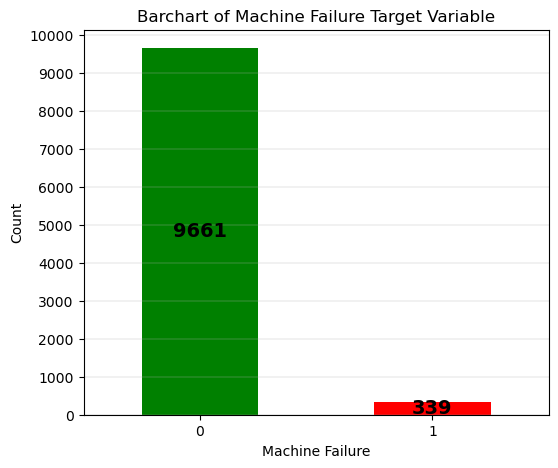

In [10]:
# Barchart for the 'Machine failure' binary categorical target variable.
dfg = PM_df['Machine failure'].value_counts()
ax = dfg.plot(kind='bar', title='Barchart of Machine Failure Target Variable', ylabel='Count', xlabel='Machine Failure', color= ['green', 'red'], rot=0, figsize=(6,5))
ax.bar_label(ax.containers[0], label_type='center', color='black', fontsize=14, fontweight='bold')
plt.yticks(np.arange(0,10001,step=1000))
plt.grid(axis='y', linewidth=0.25)
plt.show()

In [11]:
# Evaluate the 'Type' categorical variable.
PM_df['Type'].value_counts()

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

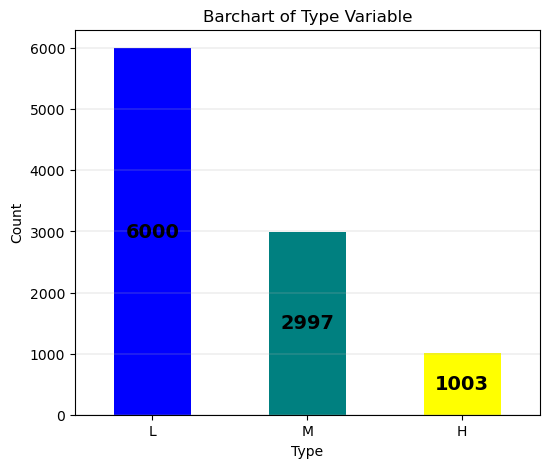

In [12]:
# Barchart for the 'Type' categorical variable.
dfg = PM_df['Type'].value_counts()
ax = dfg.plot(kind='bar', title='Barchart of Type Variable', ylabel='Count', xlabel='Type', color= ['blue', 'teal', 'yellow'], rot=0, figsize=(6,5))
ax.bar_label(ax.containers[0], label_type='center', color='black', fontsize=14, fontweight='bold')
plt.yticks(np.arange(0,6001,step=1000))
plt.grid(axis='y', linewidth=0.25)
plt.show()

C:\Users\rcc_0\AppData\Local\Temp\ipykernel_4492\941307571.py:27: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(i - width/2, data['Total Count'][i] + 50, str(int(data['Total Count'][i])), ha='center', fontsize=12)
C:\Users\rcc_0\AppData\Local\Temp\ipykernel_4492\941307571.py:28: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(i + width/2, data['Failure Count'][i] + 50, str(int(data['Failure Count'][i])), ha='center', fontsize=12)


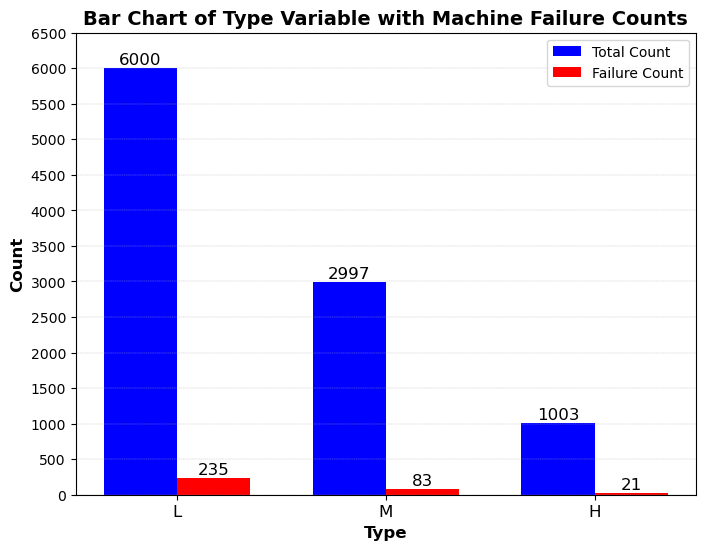

In [13]:
# Calculate total counts and failure counts by Type
total_counts = PM_df['Type'].value_counts()
failure_counts = PM_df[PM_df['Machine failure'] == 1]['Type'].value_counts()

# Create a DataFrame for plotting
data = pd.DataFrame({'Total Count': total_counts, 'Failure Count': failure_counts}).fillna(0)

# Plot grouped bar chart
fig, ax = plt.subplots(figsize=(8, 6))
width = 0.35  # Width of bars

# Positions for bars
positions = range(len(data))
ax.bar([p - width/2 for p in positions], data['Total Count'], width, label='Total Count', color='blue')
ax.bar([p + width/2 for p in positions], data['Failure Count'], width, label='Failure Count', color='red')

# Labels and title
ax.set_xlabel('Type', fontsize=12, fontweight='bold')
ax.set_ylabel('Count', fontsize=12, fontweight='bold')
ax.set_title('Bar Chart of Type Variable with Machine Failure Counts', fontsize=14, fontweight='bold')
ax.set_xticks(positions)
ax.set_xticklabels(data.index, fontsize=12)
ax.legend()

# Add value labels on bars
for i in range(len(data)):
    ax.text(i - width/2, data['Total Count'][i] + 50, str(int(data['Total Count'][i])), ha='center', fontsize=12)
    ax.text(i + width/2, data['Failure Count'][i] + 50, str(int(data['Failure Count'][i])), ha='center', fontsize=12)

# Rotate x-ticks if needed and add grid
plt.xticks(rotation=0)
plt.yticks(np.arange(0, 6501, step=500))
plt.grid(axis='y', linestyle='--', linewidth=0.25)
plt.show()

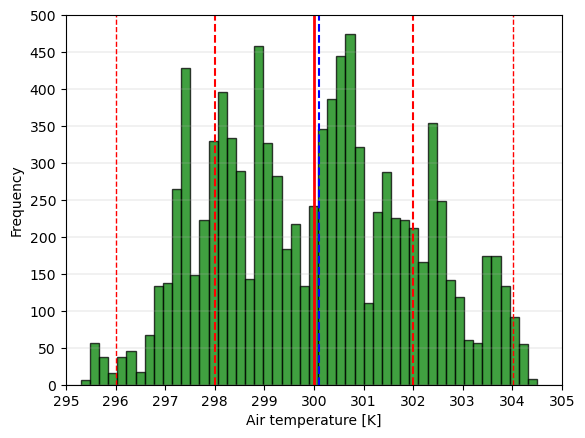

In [15]:
# Histogram for the 'Air temperature [K]' continuous variable.
plt.hist(PM_df['Air temperature [K]'], bins = 50, alpha = 0.75, color = 'green', edgecolor = 'black')
plt.xlabel('Air temperature [K]')
plt.ylabel('Frequency')
plt.xlim(295, 305)
plt.xticks(np.arange(295,306,step=1))
plt.yticks(np.arange(0,501,step=50))

mean_value = PM_df['Air temperature [K]'].mean()
median_value = PM_df['Air temperature [K]'].median()
std_value = PM_df['Air temperature [K]'].std()

plt.axvline(mean_value, color='red', linewidth=2, label=f'Mean: {mean_value: .2f}')
plt.axvline(median_value, color='blue', linestyle='dashed', linewidth=1.5, label=f'Median: {median_value: .2f}')
plt.axvline(mean_value+std_value, color='red', linestyle='dashed', linewidth=1.5, label=f'1 SD')
plt.axvline(mean_value-std_value, color='red', linestyle='dashed', linewidth=1.5)
plt.axvline(mean_value+2*std_value, color='red', linestyle='dashed', linewidth=1, label=f'2 SD')
plt.axvline(mean_value-2*std_value, color='red', linestyle='dashed', linewidth=1)
plt.axvline(mean_value+3*std_value, color='red', linestyle='dashed', linewidth=0.5, label=f'3 SD')
plt.axvline(mean_value-3*std_value, color='red', linestyle='dashed', linewidth=0.5)

plt.grid(axis='y', linewidth=0.25)
plt.show()

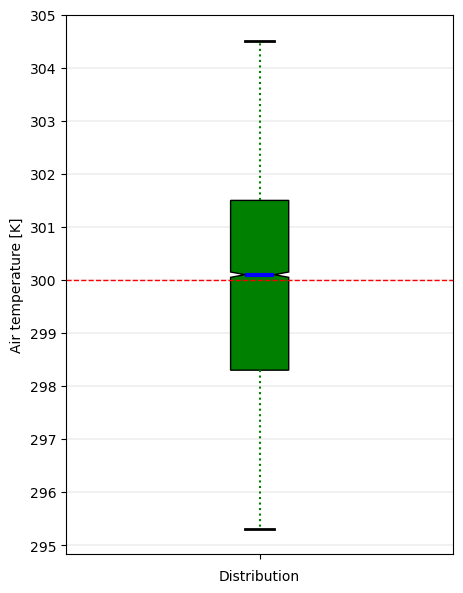

In [16]:
# Boxplot for the 'Air temperature [K]' continuous variable.
fig = plt.figure(figsize =(5, 7))
ax = fig.add_subplot(111)

# Creating axes instance
bp = ax.boxplot(PM_df['Air temperature [K]'], patch_artist = True,
                notch ='True')

for patch, color in zip(bp['boxes'], 'green'):
    patch.set_facecolor('green')

# Changing color and linewidth of whiskers.
for whisker in bp['whiskers']:
    whisker.set(color ='green',
                linewidth = 1.5,
                linestyle =":")

# Changing color and linewidth of caps.
for cap in bp['caps']:
    cap.set(color ='black',
            linewidth = 2)

# Changing color and linewidth of median.
for median in bp['medians']:
    median.set(color ='blue',
               linewidth = 3)
    
# Changing style of fliers.
for flier in bp['fliers']:
    flier.set(marker ='D',
              alpha = 0.5)
    
# Set axis labels.
ax.set_xlabel('Distribution')
ax.set_ylabel('Air temperature [K]')  
ax.set_xticklabels('')

# Set axis limits.
plt.yticks(np.arange(295,306,step=1)) 

# Display the mean.
plt.axhline(mean_value, color='red', linewidth=1, linestyle='dashed', label=f'Mean: {mean_value: .2f}')

plt.grid(axis='y', linewidth=0.25)
plt.show()

In [17]:
# 'Air temperature [K]' Anderson-Darling Normality Test
result = anderson(PM_df['Air temperature [K]'])
print('Statistic: %.3f' % result.statistic)
p = 0
for i in range(len(result.critical_values)):
	sl, cv = result.significance_level[i], result.critical_values[i]
	if result.statistic < result.critical_values[i]:
		print('%.3f: %.3f, data looks normal (fail to reject H0)' % (sl, cv))
	else:
		print('%.3f: %.3f, data does not look normal (reject H0)' % (sl, cv))

Statistic: 53.685
15.000: 0.576, data does not look normal (reject H0)
10.000: 0.656, data does not look normal (reject H0)
5.000: 0.787, data does not look normal (reject H0)
2.500: 0.918, data does not look normal (reject H0)
1.000: 1.092, data does not look normal (reject H0)


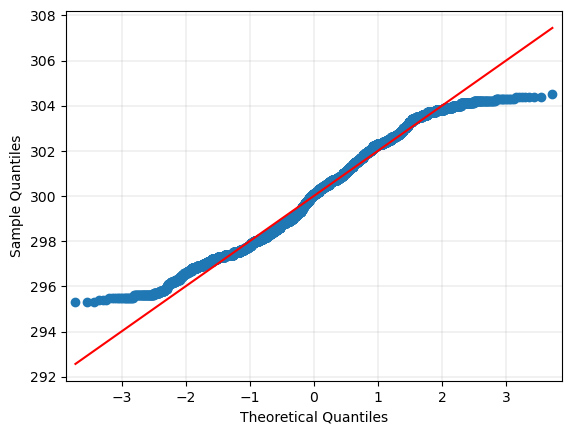

In [18]:
# 'Air temperature [K]' QQ plot
qqplot(PM_df['Air temperature [K]'], line='s')
plt.grid(linewidth=0.25)
plt.show()

In [19]:
# 'Air temperature [K]' Skewness & Kurtosis
print(f'Skewness: {skew(PM_df['Air temperature [K]']).round(3)}')
print(f'Kurtosis: {kurtosis(PM_df['Air temperature [K]']).round(3)}')

Skewness: 0.114
Kurtosis: -0.836


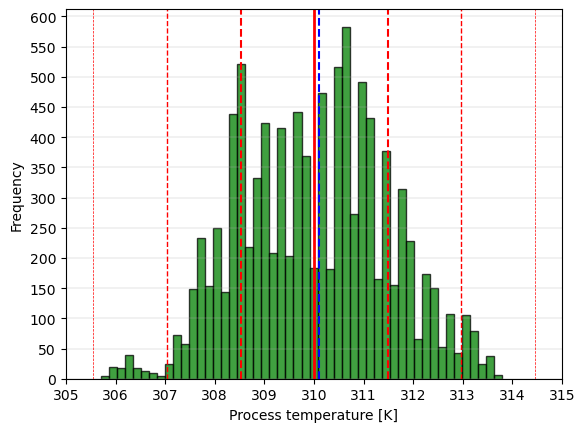

In [22]:
# Histogram for the 'Process temperature [K]' continuous variable.
plt.hist(PM_df['Process temperature [K]'], bins = 50, alpha = 0.75, color = 'green', edgecolor = 'black')
plt.xlabel('Process temperature [K]')
plt.ylabel('Frequency')
plt.xlim(305, 315)
plt.xticks(np.arange(305,316,step=1))
plt.yticks(np.arange(0,601,step=50))

mean_value = PM_df['Process temperature [K]'].mean()
median_value = PM_df['Process temperature [K]'].median()
std_value = PM_df['Process temperature [K]'].std()

plt.axvline(mean_value, color='red', linewidth=2, label=f'Mean: {mean_value: .2f}')
plt.axvline(median_value, color='blue', linestyle='dashed', linewidth=1.5, label=f'Median: {median_value: .2f}')
plt.axvline(mean_value+std_value, color='red', linestyle='dashed', linewidth=1.5, label=f'1 SD')
plt.axvline(mean_value-std_value, color='red', linestyle='dashed', linewidth=1.5)
plt.axvline(mean_value+2*std_value, color='red', linestyle='dashed', linewidth=1, label=f'2 SD')
plt.axvline(mean_value-2*std_value, color='red', linestyle='dashed', linewidth=1)
plt.axvline(mean_value+3*std_value, color='red', linestyle='dashed', linewidth=0.5, label=f'3 SD')
plt.axvline(mean_value-3*std_value, color='red', linestyle='dashed', linewidth=0.5)

plt.grid(axis='y', linewidth=0.25)
plt.show()

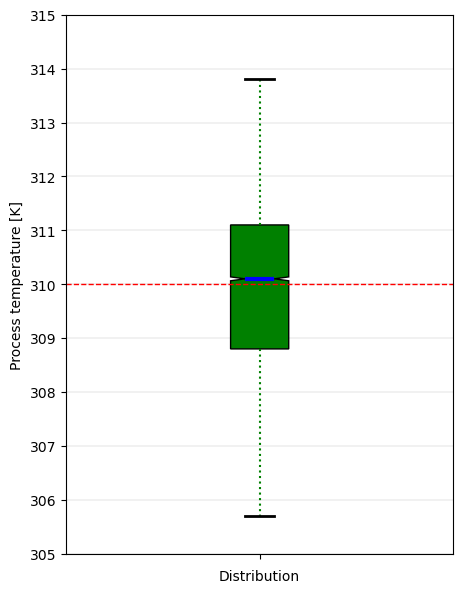

In [23]:
# Boxplot for the 'Process temperature [K]' continuous variable.
fig = plt.figure(figsize =(5, 7))
ax = fig.add_subplot(111)

# Creating axes instance
bp = ax.boxplot(PM_df['Process temperature [K]'], patch_artist = True,
                notch ='True')

for patch, color in zip(bp['boxes'], 'green'):
    patch.set_facecolor('green')

# Changing color and linewidth of whiskers.
for whisker in bp['whiskers']:
    whisker.set(color ='green',
                linewidth = 1.5,
                linestyle =":")

# Changing color and linewidth of caps.
for cap in bp['caps']:
    cap.set(color ='black',
            linewidth = 2)

# Changing color and linewidth of median.
for median in bp['medians']:
    median.set(color ='blue',
               linewidth = 3)
    
# Changing style of fliers.
for flier in bp['fliers']:
    flier.set(marker ='D',
              alpha = 0.5)
    
# Set axis labels.
ax.set_xlabel('Distribution')
ax.set_ylabel('Process temperature [K]')  
ax.set_xticklabels('')

# Set axis limits.
plt.yticks(np.arange(305,316,step=1)) 

# Display the mean.
plt.axhline(mean_value, color='red', linewidth=1, linestyle='dashed', label=f'Mean: {mean_value: .2f}')

plt.grid(axis='y', linewidth=0.25)
plt.show() 

In [24]:
# 'Process temperature [K]' Anderson-Darling Normality Test
result = anderson(PM_df['Process temperature [K]'])
print('Statistic: %.3f' % result.statistic)
p = 0
for i in range(len(result.critical_values)):
	sl, cv = result.significance_level[i], result.critical_values[i]
	if result.statistic < result.critical_values[i]:
		print('%.3f: %.3f, data looks normal (fail to reject H0)' % (sl, cv))
	else:
		print('%.3f: %.3f, data does not look normal (reject H0)' % (sl, cv))

Statistic: 24.014
15.000: 0.576, data does not look normal (reject H0)
10.000: 0.656, data does not look normal (reject H0)
5.000: 0.787, data does not look normal (reject H0)
2.500: 0.918, data does not look normal (reject H0)
1.000: 1.092, data does not look normal (reject H0)


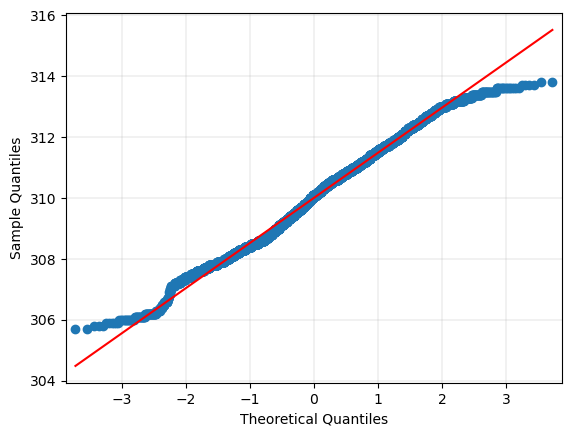

In [25]:
# 'Process temperature [K]' QQ plot
qqplot(PM_df['Process temperature [K]'], line='s')
plt.grid(linewidth=0.25)
plt.show()

In [26]:
# 'Process temperature [K]' Skewness & Kurtosis
print(f'Skewness: {skew(PM_df['Process temperature [K]']).round(3)}')
print(f'Kurtosis: {kurtosis(PM_df['Process temperature [K]']).round(3)}')

Skewness: 0.015
Kurtosis: -0.5


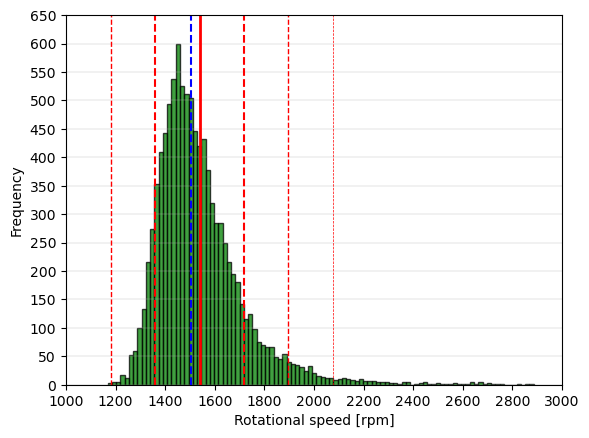

In [27]:
# Histogram for the 'Rotational speed [rpm]' continuous variable.
plt.hist(PM_df['Rotational speed [rpm]'], bins = 100, alpha = 0.75, color = 'green', edgecolor = 'black')
plt.xlabel('Rotational speed [rpm]')
plt.ylabel('Frequency')
plt.xlim(1000, 3000)
plt.xticks(np.arange(1000,3001,step=200))
plt.yticks(np.arange(0,651,step=50))

mean_value = PM_df['Rotational speed [rpm]'].mean()
median_value = PM_df['Rotational speed [rpm]'].median()
std_value = PM_df['Rotational speed [rpm]'].std()

plt.axvline(mean_value, color='red', linewidth=2, label=f'Mean: {mean_value: .2f}')
plt.axvline(median_value, color='blue', linestyle='dashed', linewidth=1.5, label=f'Median: {median_value: .2f}')
plt.axvline(mean_value+std_value, color='red', linestyle='dashed', linewidth=1.5, label=f'1 SD')
plt.axvline(mean_value-std_value, color='red', linestyle='dashed', linewidth=1.5)
plt.axvline(mean_value+2*std_value, color='red', linestyle='dashed', linewidth=1, label=f'2 SD')
plt.axvline(mean_value-2*std_value, color='red', linestyle='dashed', linewidth=1)
plt.axvline(mean_value+3*std_value, color='red', linestyle='dashed', linewidth=0.5, label=f'3 SD')
plt.axvline(mean_value-3*std_value, color='red', linestyle='dashed', linewidth=0.5)

plt.grid(axis='y', linewidth=0.25)
plt.show()

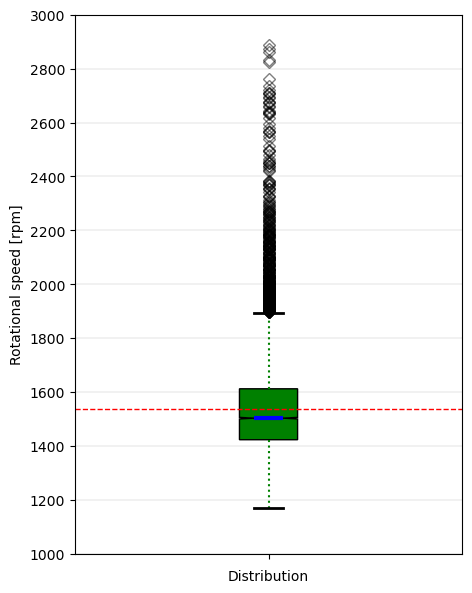

In [28]:
# Boxplot for the 'Rotational speed [rpm]' continuous variable.
fig = plt.figure(figsize =(5, 7))
ax = fig.add_subplot(111)

# Creating axes instance
bp = ax.boxplot(PM_df['Rotational speed [rpm]'], patch_artist = True,
                notch ='True')

for patch, color in zip(bp['boxes'], 'green'):
    patch.set_facecolor('green')

# Changing color and linewidth of whiskers.
for whisker in bp['whiskers']:
    whisker.set(color ='green',
                linewidth = 1.5,
                linestyle =":")

# Changing color and linewidth of caps.
for cap in bp['caps']:
    cap.set(color ='black',
            linewidth = 2)

# Changing color and linewidth of median.
for median in bp['medians']:
    median.set(color ='blue',
               linewidth = 3)
    
# Changing style of fliers.
for flier in bp['fliers']:
    flier.set(marker ='D',
              alpha = 0.5)
    
# Set axis labels.
ax.set_xlabel('Distribution')
ax.set_ylabel('Rotational speed [rpm]')  
ax.set_xticklabels('')

# Set axis limits.
plt.yticks(np.arange(1000,3001,step=200)) 

# Display the mean.
plt.axhline(mean_value, color='red', linewidth=1, linestyle='dashed', label=f'Mean: {mean_value: .2f}')

plt.grid(axis='y', linewidth=0.25)
plt.show() 

In [29]:
# 'Rotational speed [rpm]' Anderson-Darling Normality Test
result = anderson(PM_df['Rotational speed [rpm]'])
print('Statistic: %.3f' % result.statistic)
p = 0
for i in range(len(result.critical_values)):
	sl, cv = result.significance_level[i], result.critical_values[i]
	if result.statistic < result.critical_values[i]:
		print('%.3f: %.3f, data looks normal (fail to reject H0)' % (sl, cv))
	else:
		print('%.3f: %.3f, data does not look normal (reject H0)' % (sl, cv))

Statistic: 254.285
15.000: 0.576, data does not look normal (reject H0)
10.000: 0.656, data does not look normal (reject H0)
5.000: 0.787, data does not look normal (reject H0)
2.500: 0.918, data does not look normal (reject H0)
1.000: 1.092, data does not look normal (reject H0)


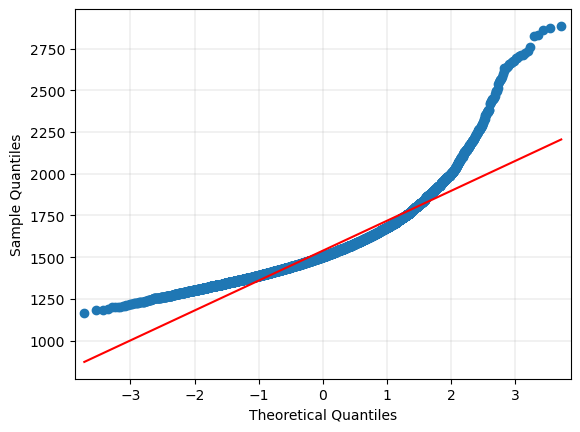

In [30]:
# 'Rotational speed [rpm]' QQ plot
qqplot(PM_df['Rotational speed [rpm]'], line='s')
plt.grid(linewidth=0.25)
plt.show()

In [31]:
# 'Rotational speed [rpm]' Skewness & Kurtosis
print(f'Skewness: {skew(PM_df['Rotational speed [rpm]']).round(3)}')
print(f'Kurtosis: {kurtosis(PM_df['Rotational speed [rpm]']).round(3)}')

Skewness: 1.993
Kurtosis: 7.389


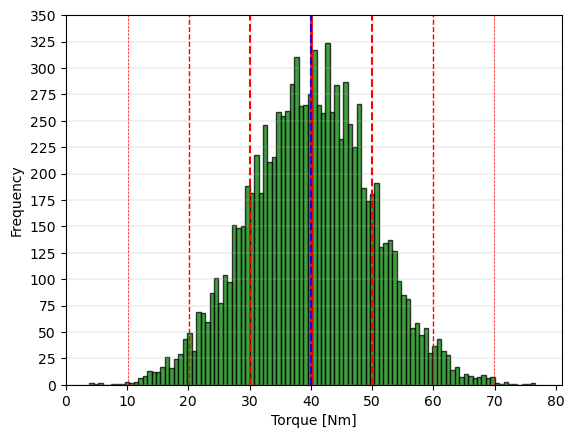

In [32]:
# Histogram for the 'Torque [Nm]' continuous variable.
plt.hist(PM_df['Torque [Nm]'], bins = 100, alpha = 0.75, color = 'green', edgecolor = 'black')
plt.xlabel('Torque [Nm]')
plt.ylabel('Frequency')
plt.xlim(0, 81)
plt.xticks(np.arange(0,81,step=10))
plt.yticks(np.arange(0,351,step=25))

mean_value = PM_df['Torque [Nm]'].mean()
median_value = PM_df['Torque [Nm]'].median()
std_value = PM_df['Torque [Nm]'].std()

plt.axvline(mean_value, color='red', linewidth=2, label=f'Mean: {mean_value: .2f}')
plt.axvline(median_value, color='blue', linestyle='dashed', linewidth=1.5, label=f'Median: {median_value: .2f}')
plt.axvline(mean_value+std_value, color='red', linestyle='dashed', linewidth=1.5, label=f'1 SD')
plt.axvline(mean_value-std_value, color='red', linestyle='dashed', linewidth=1.5)
plt.axvline(mean_value+2*std_value, color='red', linestyle='dashed', linewidth=1, label=f'2 SD')
plt.axvline(mean_value-2*std_value, color='red', linestyle='dashed', linewidth=1)
plt.axvline(mean_value+3*std_value, color='red', linestyle='dashed', linewidth=0.5, label=f'3 SD')
plt.axvline(mean_value-3*std_value, color='red', linestyle='dashed', linewidth=0.5)

plt.grid(axis='y', linewidth=0.25)
plt.show()

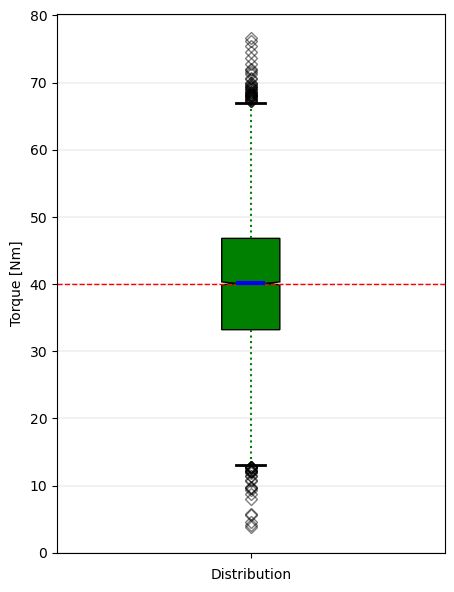

In [33]:
# Boxplot for the 'Torque [Nm]' continuous variable.
fig = plt.figure(figsize =(5, 7))
ax = fig.add_subplot(111)

# Creating axes instance
bp = ax.boxplot(PM_df['Torque [Nm]'], patch_artist = True,
                notch ='True')

for patch, color in zip(bp['boxes'], 'green'):
    patch.set_facecolor('green')

# Changing color and linewidth of whiskers.
for whisker in bp['whiskers']:
    whisker.set(color ='green',
                linewidth = 1.5,
                linestyle =":")

# Changing color and linewidth of caps.
for cap in bp['caps']:
    cap.set(color ='black',
            linewidth = 2)

# Changing color and linewidth of median.
for median in bp['medians']:
    median.set(color ='blue',
               linewidth = 3)
    
# Changing style of fliers.
for flier in bp['fliers']:
    flier.set(marker ='D',
              alpha = 0.5)
    
# Set axis labels.
ax.set_xlabel('Distribution')
ax.set_ylabel('Torque [Nm]')  
ax.set_xticklabels('')

# Set axis limits.
plt.yticks(np.arange(0,81,step=10)) 

# Display the mean.
plt.axhline(mean_value, color='red', linewidth=1, linestyle='dashed', label=f'Mean: {mean_value: .2f}')

plt.grid(axis='y', linewidth=0.25)
plt.show() 

In [34]:
# 'Torque [Nm]' Anderson-Darling Normality Test
result = anderson(PM_df['Torque [Nm]'])
print('Statistic: %.3f' % result.statistic)
p = 0
for i in range(len(result.critical_values)):
	sl, cv = result.significance_level[i], result.critical_values[i]
	if result.statistic < result.critical_values[i]:
		print('%.3f: %.3f, data looks normal (fail to reject H0)' % (sl, cv))
	else:
		print('%.3f: %.3f, data does not look normal (reject H0)' % (sl, cv))

Statistic: 0.591
15.000: 0.576, data does not look normal (reject H0)
10.000: 0.656, data looks normal (fail to reject H0)
5.000: 0.787, data looks normal (fail to reject H0)
2.500: 0.918, data looks normal (fail to reject H0)
1.000: 1.092, data looks normal (fail to reject H0)


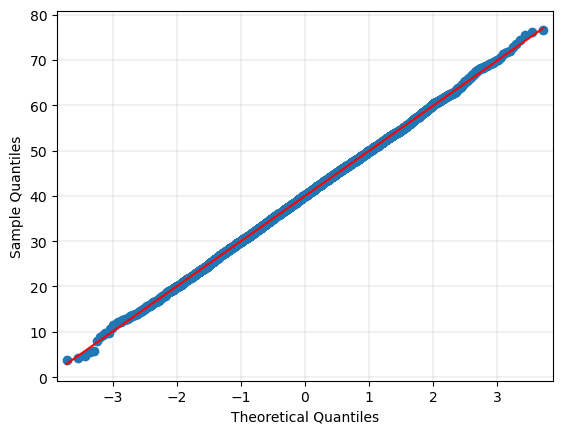

In [35]:
# 'Torque [Nm]' QQ plot
qqplot(PM_df['Torque [Nm]'], line='s')
plt.grid(linewidth=0.25)
plt.show()

In [36]:
# 'Torque [Nm]' Skewness & Kurtosis
print(f'Skewness: {skew(PM_df['Torque [Nm]']).round(3)}')
print(f'Kurtosis: {kurtosis(PM_df['Torque [Nm]']).round(3)}')

Skewness: -0.01
Kurtosis: -0.014


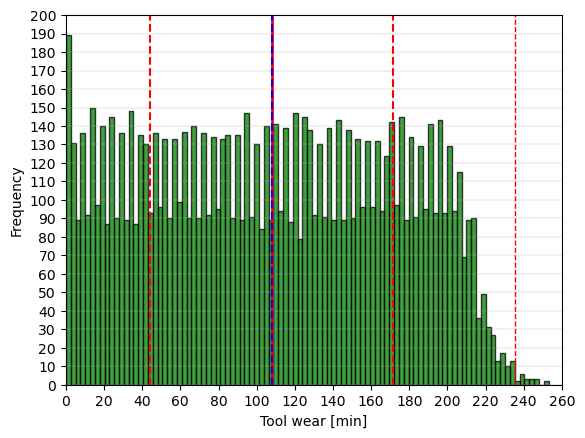

In [37]:
# Histogram for the 'Tool wear [min]' continuous variable.
plt.hist(PM_df['Tool wear [min]'], bins = 100, alpha = 0.75, color = 'green', edgecolor = 'black')
plt.xlabel('Tool wear [min]')
plt.ylabel('Frequency')
plt.xlim(0, 81)
plt.xticks(np.arange(0,261,step=20))
plt.yticks(np.arange(0,201,step=10))

mean_value = PM_df['Tool wear [min]'].mean()
median_value = PM_df['Tool wear [min]'].median()
std_value = PM_df['Tool wear [min]'].std()

plt.axvline(mean_value, color='red', linewidth=2, label=f'Mean: {mean_value: .2f}')
plt.axvline(median_value, color='blue', linestyle='dashed', linewidth=1.5, label=f'Median: {median_value: .2f}')
plt.axvline(mean_value+std_value, color='red', linestyle='dashed', linewidth=1.5, label=f'1 SD')
plt.axvline(mean_value-std_value, color='red', linestyle='dashed', linewidth=1.5)
plt.axvline(mean_value+2*std_value, color='red', linestyle='dashed', linewidth=1, label=f'2 SD')
plt.axvline(mean_value-2*std_value, color='red', linestyle='dashed', linewidth=1)
plt.axvline(mean_value+3*std_value, color='red', linestyle='dashed', linewidth=0.5, label=f'3 SD')
plt.axvline(mean_value-3*std_value, color='red', linestyle='dashed', linewidth=0.5)

plt.grid(axis='y', linewidth=0.25)
plt.show()

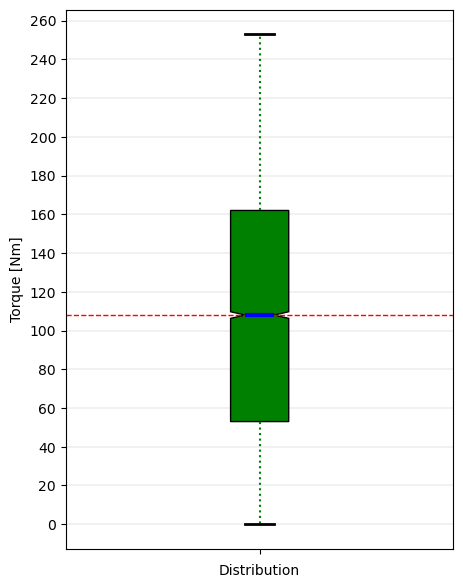

In [38]:
# Boxplot for the 'Tool wear [min]' continuous variable.
fig = plt.figure(figsize =(5, 7))
ax = fig.add_subplot(111)

# Creating axes instance
bp = ax.boxplot(PM_df['Tool wear [min]'], patch_artist = True,
                notch ='True')

for patch, color in zip(bp['boxes'], 'green'):
    patch.set_facecolor('green')

# Changing color and linewidth of whiskers.
for whisker in bp['whiskers']:
    whisker.set(color ='green',
                linewidth = 1.5,
                linestyle =":")

# Changing color and linewidth of caps.
for cap in bp['caps']:
    cap.set(color ='black',
            linewidth = 2)

# Changing color and linewidth of median.
for median in bp['medians']:
    median.set(color ='blue',
               linewidth = 3)
    
# Changing style of fliers.
for flier in bp['fliers']:
    flier.set(marker ='D',
              alpha = 0.5)
    
# Set axis labels.
ax.set_xlabel('Distribution')
ax.set_ylabel('Torque [Nm]')  
ax.set_xticklabels('')

# Set axis limits.
plt.yticks(np.arange(0,261,step=20)) 

# Display the mean.
plt.axhline(mean_value, color='red', linewidth=1, linestyle='dashed', label=f'Mean: {mean_value: .2f}')

plt.grid(axis='y', linewidth=0.25)
plt.show() 

In [39]:
# 'Tool wear [min]' Anderson-Darling Normality Test
result = anderson(PM_df['Tool wear [min]'])
print('Statistic: %.3f' % result.statistic)
p = 0
for i in range(len(result.critical_values)):
	sl, cv = result.significance_level[i], result.critical_values[i]
	if result.statistic < result.critical_values[i]:
		print('%.3f: %.3f, data looks normal (fail to reject H0)' % (sl, cv))
	else:
		print('%.3f: %.3f, data does not look normal (reject H0)' % (sl, cv))

Statistic: 103.650
15.000: 0.576, data does not look normal (reject H0)
10.000: 0.656, data does not look normal (reject H0)
5.000: 0.787, data does not look normal (reject H0)
2.500: 0.918, data does not look normal (reject H0)
1.000: 1.092, data does not look normal (reject H0)


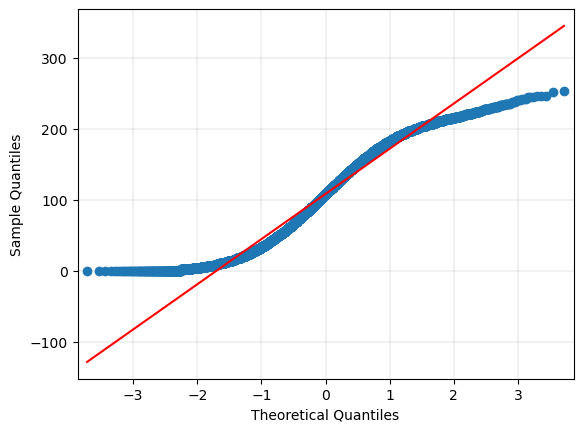

In [40]:
# 'Tool wear [min]' QQ plot
qqplot(PM_df['Tool wear [min]'], line='s')
plt.grid(linewidth=0.25)
plt.show()

In [41]:
# 'Tool wear [min]' Skewness & Kurtosis
print(f'Skewness: {skew(PM_df['Tool wear [min]']).round(3)}')
print(f'Kurtosis: {kurtosis(PM_df['Tool wear [min]']).round(3)}')

Skewness: 0.027
Kurtosis: -1.167


Data Preprocessing And Feature Engineering For Modeling Dataset

In [ ]:
# Encode 'Type'
le = LabelEncoder()
PM_df['Type'] = le.fit_transform(PM_df['Type'])
print("\nEncoded 'Type' unique values:", PM_df['Type'].unique())

# Feature Engineering
PM_df['Temp_diff'] = PM_df['Process temperature [K]'] - PM_df['Air temperature [K]']  # HDF
PM_df['Rot_speed_rad/s'] = PM_df['Rotational speed [rpm]'] * (2 * np.pi / 60)  # Convert rpm to rad/s
PM_df['Power'] = PM_df['Torque [Nm]'] * PM_df['Rot_speed_rad/s']  # PWF, power in Nm*rad/s
PM_df['Tool_Torque'] = PM_df['Tool wear [min]'] * PM_df['Torque [Nm]']  # OSF
features = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]',
            'Torque [Nm]', 'Tool wear [min]', 'Type', 'Temp_diff', 'Rot_speed_rad/s',
            'Power', 'Tool_Torque']

# Save processed data
df_processed = PM_df[features + ['Machine failure'] + ['UDI']]
df_processed.to_csv('processed_ai4i2020.csv', index=False)
print("\nProcessed Data Saved to 'processed_ai4i2020.csv'")

# Summary statistics
print("\nProcessed Data Description:")
df_processed.describe()


Encoded 'Type' unique values: [2 1 0]

Processed Data Saved to 'processed_ai4i2020.csv'

Processed Data Description:


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type,Temp_diff,Rot_speed_rad/s,Power,Tool_Torque,Machine failure,UDI
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000,1.19940,10.000630,161.140256,6279.744953,4314.664550,0.033900,5000.50000
std,2.000259,1.483734,179.284096,9.968934,63.654147,0.60023,1.001094,18.774587,1067.418295,2826.567692,0.180981,2886.89568
min,295.300000,305.700000,1168.000000,3.800000,0.000000,0.00000,7.600000,122.312674,1148.440610,0.000000,0.000000,1.00000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000,1.00000,9.300000,149.016212,5561.184484,1963.650000,0.000000,2500.75000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000,1.00000,9.800000,157.393792,6271.027344,4012.950000,0.000000,5000.50000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000,2.00000,11.000000,168.808245,7003.002724,6279.000000,0.000000,7500.25000
max,304.500000,313.800000,2886.000000,76.600000,253.000000,2.00000,12.100000,302.221213,10469.923005,16497.000000,1.000000,10000.00000


Exploratory Data Analysis For Feature Engineered Variables

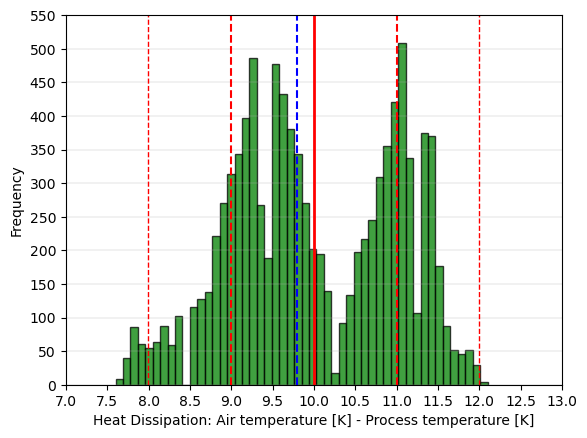

In [44]:
# Histogram for the 'Temp_diff' continuous variable.
plt.hist(PM_df['Temp_diff'], bins = 50, alpha = 0.75, color = 'green', edgecolor = 'black')
plt.xlabel('Heat Dissipation: Air temperature [K] - Process temperature [K]')
plt.ylabel('Frequency')
plt.xlim(7, 13)
plt.xticks(np.arange(7,13.1,step=0.5))
plt.yticks(np.arange(0,551,step=50))

mean_value = PM_df['Temp_diff'].mean()
median_value = PM_df['Temp_diff'].median()
std_value = PM_df['Temp_diff'].std()

plt.axvline(mean_value, color='red', linewidth=2, label=f'Mean: {mean_value: .2f}')
plt.axvline(median_value, color='blue', linestyle='dashed', linewidth=1.5, label=f'Median: {median_value: .2f}')
plt.axvline(mean_value+std_value, color='red', linestyle='dashed', linewidth=1.5, label=f'1 SD')
plt.axvline(mean_value-std_value, color='red', linestyle='dashed', linewidth=1.5)
plt.axvline(mean_value+2*std_value, color='red', linestyle='dashed', linewidth=1, label=f'2 SD')
plt.axvline(mean_value-2*std_value, color='red', linestyle='dashed', linewidth=1)
plt.axvline(mean_value+3*std_value, color='red', linestyle='dashed', linewidth=0.5, label=f'3 SD')
plt.axvline(mean_value-3*std_value, color='red', linestyle='dashed', linewidth=0.5)

plt.grid(axis='y', linewidth=0.25)
plt.show()

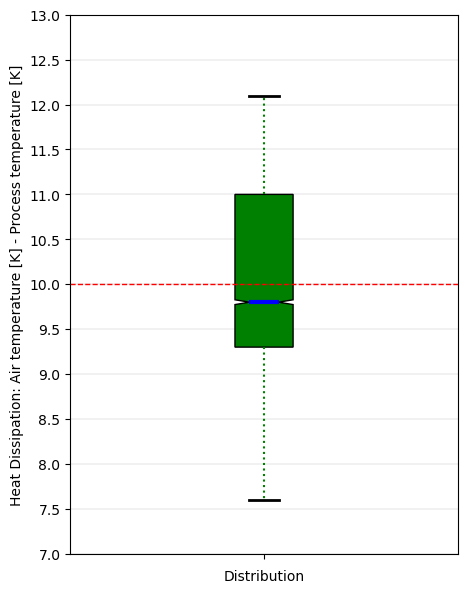

In [45]:
# Boxplot for the 'Temp_diff' continuous variable.
fig = plt.figure(figsize =(5, 7))
ax = fig.add_subplot(111)

# Creating axes instance
bp = ax.boxplot(PM_df['Temp_diff'], patch_artist = True,
                notch ='True')

for patch, color in zip(bp['boxes'], 'green'):
    patch.set_facecolor('green')

# Changing color and linewidth of whiskers.
for whisker in bp['whiskers']:
    whisker.set(color ='green',
                linewidth = 1.5,
                linestyle =":")

# Changing color and linewidth of caps.
for cap in bp['caps']:
    cap.set(color ='black',
            linewidth = 2)

# Changing color and linewidth of median.
for median in bp['medians']:
    median.set(color ='blue',
               linewidth = 3)
    
# Changing style of fliers.
for flier in bp['fliers']:
    flier.set(marker ='D',
              alpha = 0.5)
    
# Set axis labels.
ax.set_xlabel('Distribution')
ax.set_ylabel('Heat Dissipation: Air temperature [K] - Process temperature [K]')  
ax.set_xticklabels('')

# Set axis limits.
plt.yticks(np.arange(7,13.1,step=0.5)) 

# Display the mean.
plt.axhline(mean_value, color='red', linewidth=1, linestyle='dashed', label=f'Mean: {mean_value: .2f}')

plt.grid(axis='y', linewidth=0.25)
plt.show() 

In [46]:
# 'Temp_diff' Anderson-Darling Normality Test
result = anderson(PM_df['Temp_diff'])
print('Statistic: %.3f' % result.statistic)
p = 0
for i in range(len(result.critical_values)):
	sl, cv = result.significance_level[i], result.critical_values[i]
	if result.statistic < result.critical_values[i]:
		print('%.3f: %.3f, data looks normal (fail to reject H0)' % (sl, cv))
	else:
		print('%.3f: %.3f, data does not look normal (reject H0)' % (sl, cv))

Statistic: 150.907
15.000: 0.576, data does not look normal (reject H0)
10.000: 0.656, data does not look normal (reject H0)
5.000: 0.787, data does not look normal (reject H0)
2.500: 0.918, data does not look normal (reject H0)
1.000: 1.092, data does not look normal (reject H0)


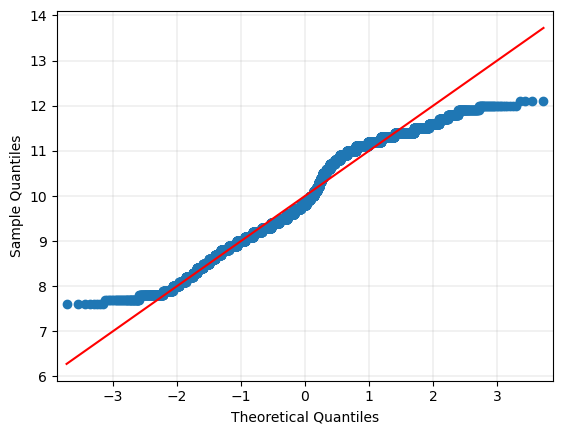

In [47]:
# 'Temp_diff' QQ plot
qqplot(PM_df['Temp_diff'], line='s')
plt.grid(linewidth=0.25)
plt.show()

In [48]:
# 'Temp_diff' Skewness & Kurtosis
print(f'Skewness: {skew(PM_df['Temp_diff']).round(3)}')
print(f'Kurtosis: {kurtosis(PM_df['Temp_diff']).round(3)}')

Skewness: -0.072
Kurtosis: -0.986


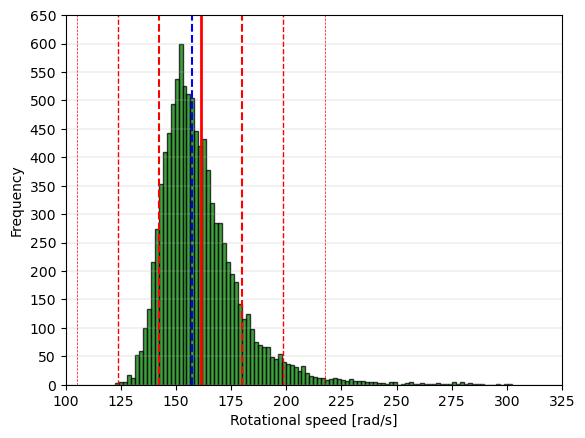

In [49]:
# Histogram for the 'Rot_speed_rad/s' continuous variable.
plt.hist(PM_df['Rot_speed_rad/s'], bins = 100, alpha = 0.75, color = 'green', edgecolor = 'black')
plt.xlabel('Rotational speed [rad/s]')
plt.ylabel('Frequency')
plt.xlim(100, 325)
plt.xticks(np.arange(100,326,step=25))
plt.yticks(np.arange(0,651,step=50))

mean_value = PM_df['Rot_speed_rad/s'].mean()
median_value = PM_df['Rot_speed_rad/s'].median()
std_value = PM_df['Rot_speed_rad/s'].std()

plt.axvline(mean_value, color='red', linewidth=2, label=f'Mean: {mean_value: .2f}')
plt.axvline(median_value, color='blue', linestyle='dashed', linewidth=1.5, label=f'Median: {median_value: .2f}')
plt.axvline(mean_value+std_value, color='red', linestyle='dashed', linewidth=1.5, label=f'1 SD')
plt.axvline(mean_value-std_value, color='red', linestyle='dashed', linewidth=1.5)
plt.axvline(mean_value+2*std_value, color='red', linestyle='dashed', linewidth=1, label=f'2 SD')
plt.axvline(mean_value-2*std_value, color='red', linestyle='dashed', linewidth=1)
plt.axvline(mean_value+3*std_value, color='red', linestyle='dashed', linewidth=0.5, label=f'3 SD')
plt.axvline(mean_value-3*std_value, color='red', linestyle='dashed', linewidth=0.5)

plt.grid(axis='y', linewidth=0.25)
plt.show()

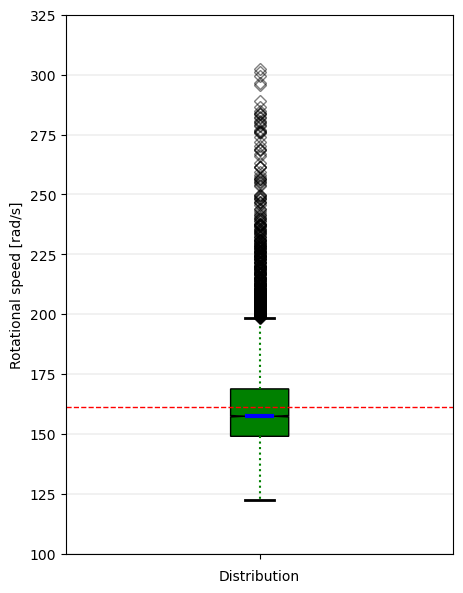

In [50]:
# Boxplot for the 'Rot_speed_rad/s' continuous variable.
fig = plt.figure(figsize =(5, 7))
ax = fig.add_subplot(111)

# Creating axes instance
bp = ax.boxplot(PM_df['Rot_speed_rad/s'], patch_artist = True,
                notch ='True')

for patch, color in zip(bp['boxes'], 'green'):
    patch.set_facecolor('green')

# Changing color and linewidth of whiskers.
for whisker in bp['whiskers']:
    whisker.set(color ='green',
                linewidth = 1.5,
                linestyle =":")

# Changing color and linewidth of caps.
for cap in bp['caps']:
    cap.set(color ='black',
            linewidth = 2)

# Changing color and linewidth of median.
for median in bp['medians']:
    median.set(color ='blue',
               linewidth = 3)
    
# Changing style of fliers.
for flier in bp['fliers']:
    flier.set(marker ='D',
              alpha = 0.5)
    
# Set axis labels.
ax.set_xlabel('Distribution')
ax.set_ylabel('Rotational speed [rad/s]')  
ax.set_xticklabels('')

# Set axis limits.
plt.yticks(np.arange(100,326,step=25)) 

# Display the mean.
plt.axhline(mean_value, color='red', linewidth=1, linestyle='dashed', label=f'Mean: {mean_value: .2f}')

plt.grid(axis='y', linewidth=0.25)
plt.show() 

In [51]:
# 'Rot_speed_rad/s' Anderson-Darling Normality Test
result = anderson(PM_df['Rot_speed_rad/s'])
print('Statistic: %.3f' % result.statistic)
p = 0
for i in range(len(result.critical_values)):
	sl, cv = result.significance_level[i], result.critical_values[i]
	if result.statistic < result.critical_values[i]:
		print('%.3f: %.3f, data looks normal (fail to reject H0)' % (sl, cv))
	else:
		print('%.3f: %.3f, data does not look normal (reject H0)' % (sl, cv))

Statistic: 254.285
15.000: 0.576, data does not look normal (reject H0)
10.000: 0.656, data does not look normal (reject H0)
5.000: 0.787, data does not look normal (reject H0)
2.500: 0.918, data does not look normal (reject H0)
1.000: 1.092, data does not look normal (reject H0)


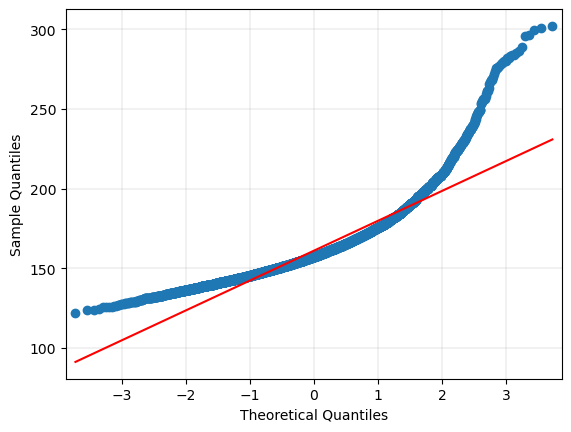

In [52]:
# 'Rot_speed_rad/s' QQ plot
qqplot(PM_df['Rot_speed_rad/s'], line='s')
plt.grid(linewidth=0.25)
plt.show()

In [53]:
# 'Rot_speed_rad/s' Skewness & Kurtosis
print(f'Skewness: {skew(PM_df['Rot_speed_rad/s']).round(3)}')
print(f'Kurtosis: {kurtosis(PM_df['Rot_speed_rad/s']).round(3)}')

Skewness: 1.993
Kurtosis: 7.389


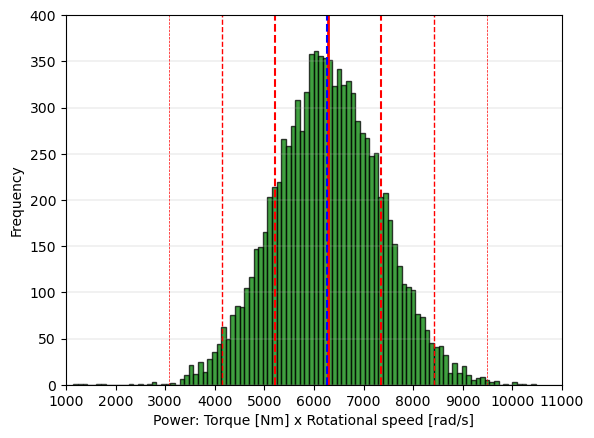

In [54]:
# Histogram for the 'Power' continuous variable.
plt.hist(PM_df['Power'], bins = 100, alpha = 0.75, color = 'green', edgecolor = 'black')
plt.xlabel('Power: Torque [Nm] x Rotational speed [rad/s]')
plt.ylabel('Frequency')
plt.xlim(1000, 11000)
plt.xticks(np.arange(1000,11001,step=1000))
plt.yticks(np.arange(0,401,step=50))

mean_value = PM_df['Power'].mean()
median_value = PM_df['Power'].median()
std_value = PM_df['Power'].std()

plt.axvline(mean_value, color='red', linewidth=2, label=f'Mean: {mean_value: .2f}')
plt.axvline(median_value, color='blue', linestyle='dashed', linewidth=1.5, label=f'Median: {median_value: .2f}')
plt.axvline(mean_value+std_value, color='red', linestyle='dashed', linewidth=1.5, label=f'1 SD')
plt.axvline(mean_value-std_value, color='red', linestyle='dashed', linewidth=1.5)
plt.axvline(mean_value+2*std_value, color='red', linestyle='dashed', linewidth=1, label=f'2 SD')
plt.axvline(mean_value-2*std_value, color='red', linestyle='dashed', linewidth=1)
plt.axvline(mean_value+3*std_value, color='red', linestyle='dashed', linewidth=0.5, label=f'3 SD')
plt.axvline(mean_value-3*std_value, color='red', linestyle='dashed', linewidth=0.5)

plt.grid(axis='y', linewidth=0.25)
plt.show()

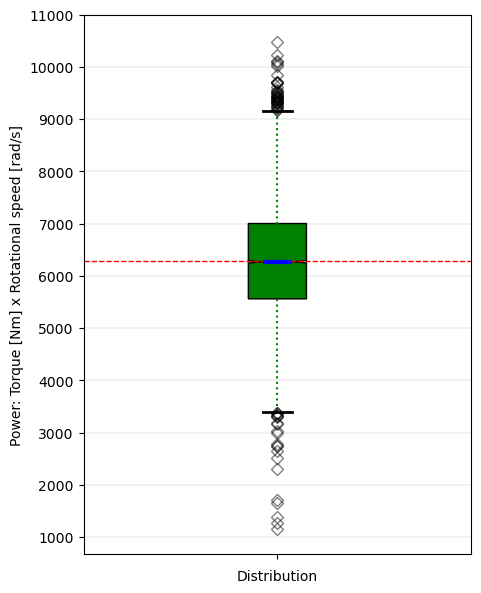

In [55]:
# Boxplot for the 'Power' continuous variable.
fig = plt.figure(figsize =(5, 7))
ax = fig.add_subplot(111)

# Creating axes instance
bp = ax.boxplot(PM_df['Power'], patch_artist = True,
                notch ='True')

for patch, color in zip(bp['boxes'], 'green'):
    patch.set_facecolor('green')

# Changing color and linewidth of whiskers.
for whisker in bp['whiskers']:
    whisker.set(color ='green',
                linewidth = 1.5,
                linestyle =":")

# Changing color and linewidth of caps.
for cap in bp['caps']:
    cap.set(color ='black',
            linewidth = 2)

# Changing color and linewidth of median.
for median in bp['medians']:
    median.set(color ='blue',
               linewidth = 3)
    
# Changing style of fliers.
for flier in bp['fliers']:
    flier.set(marker ='D',
              alpha = 0.5)
    
# Set axis labels.
ax.set_xlabel('Distribution')
ax.set_ylabel('Power: Torque [Nm] x Rotational speed [rad/s]')  
ax.set_xticklabels('')

# Set axis limits.
plt.yticks(np.arange(1000,11001,step=1000)) 

# Display the mean.
plt.axhline(mean_value, color='red', linewidth=1, linestyle='dashed', label=f'Mean: {mean_value: .2f}')

plt.grid(axis='y', linewidth=0.25)
plt.show() 

In [56]:
# 'Power' Anderson-Darling Normality Test
result = anderson(PM_df['Power'])
print('Statistic: %.3f' % result.statistic)
p = 0
for i in range(len(result.critical_values)):
	sl, cv = result.significance_level[i], result.critical_values[i]
	if result.statistic < result.critical_values[i]:
		print('%.3f: %.3f, data looks normal (fail to reject H0)' % (sl, cv))
	else:
		print('%.3f: %.3f, data does not look normal (reject H0)' % (sl, cv))

Statistic: 0.249
15.000: 0.576, data looks normal (fail to reject H0)
10.000: 0.656, data looks normal (fail to reject H0)
5.000: 0.787, data looks normal (fail to reject H0)
2.500: 0.918, data looks normal (fail to reject H0)
1.000: 1.092, data looks normal (fail to reject H0)


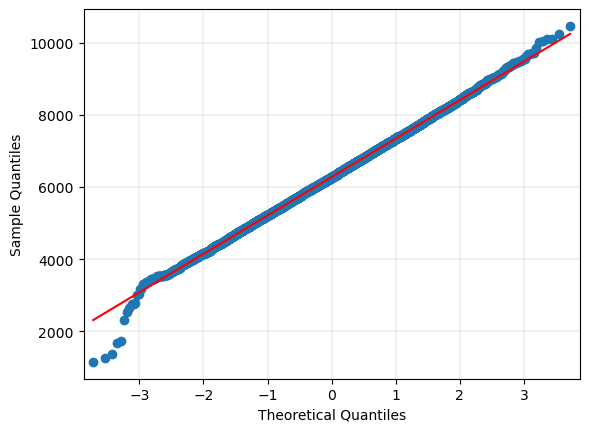

In [57]:
# 'Power' QQ plot
qqplot(PM_df['Power'], line='s')
plt.grid(linewidth=0.25)
plt.show()

In [58]:
# 'Power' Skewness & Kurtosis
print(f'Skewness: {skew(PM_df['Power']).round(3)}')
print(f'Kurtosis: {kurtosis(PM_df['Power']).round(3)}')

Skewness: 0.008
Kurtosis: 0.157


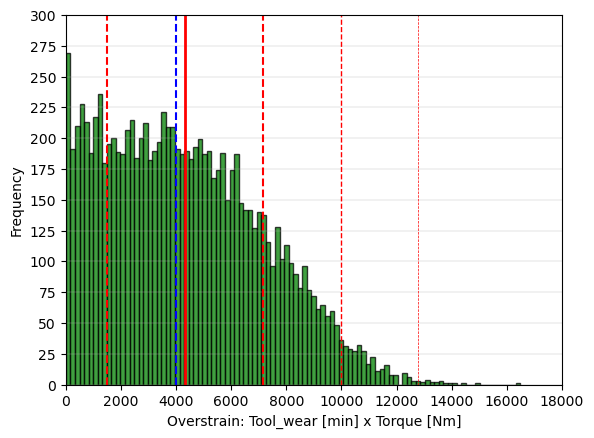

In [59]:
# Histogram for the 'Tool_Torque' continuous variable.
plt.hist(PM_df['Tool_Torque'], bins = 100, alpha = 0.75, color = 'green', edgecolor = 'black')
plt.xlabel('Overstrain: Tool_wear [min] x Torque [Nm]')
plt.ylabel('Frequency')
plt.xlim(0, 17000)
plt.xticks(np.arange(0,18001,step=2000))
plt.yticks(np.arange(0,301,step=25))

mean_value = PM_df['Tool_Torque'].mean()
median_value = PM_df['Tool_Torque'].median()
std_value = PM_df['Tool_Torque'].std()

plt.axvline(mean_value, color='red', linewidth=2, label=f'Mean: {mean_value: .2f}')
plt.axvline(median_value, color='blue', linestyle='dashed', linewidth=1.5, label=f'Median: {median_value: .2f}')
plt.axvline(mean_value+std_value, color='red', linestyle='dashed', linewidth=1.5, label=f'1 SD')
plt.axvline(mean_value-std_value, color='red', linestyle='dashed', linewidth=1.5)
plt.axvline(mean_value+2*std_value, color='red', linestyle='dashed', linewidth=1, label=f'2 SD')
plt.axvline(mean_value-2*std_value, color='red', linestyle='dashed', linewidth=1)
plt.axvline(mean_value+3*std_value, color='red', linestyle='dashed', linewidth=0.5, label=f'3 SD')
plt.axvline(mean_value-3*std_value, color='red', linestyle='dashed', linewidth=0.5)

plt.grid(axis='y', linewidth=0.25)
plt.show()

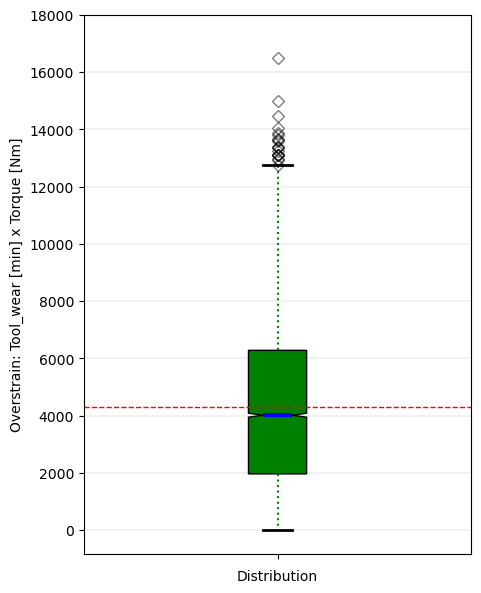

In [60]:
# Boxplot for the 'Tool_Torque' continuous variable.
fig = plt.figure(figsize =(5, 7))
ax = fig.add_subplot(111)

# Creating axes instance
bp = ax.boxplot(PM_df['Tool_Torque'], patch_artist = True,
                notch ='True')

for patch, color in zip(bp['boxes'], 'green'):
    patch.set_facecolor('green')

# Changing color and linewidth of whiskers.
for whisker in bp['whiskers']:
    whisker.set(color ='green',
                linewidth = 1.5,
                linestyle =":")

# Changing color and linewidth of caps.
for cap in bp['caps']:
    cap.set(color ='black',
            linewidth = 2)

# Changing color and linewidth of median.
for median in bp['medians']:
    median.set(color ='blue',
               linewidth = 3)
    
# Changing style of fliers.
for flier in bp['fliers']:
    flier.set(marker ='D',
              alpha = 0.5)
    
# Set axis labels.
ax.set_xlabel('Distribution')
ax.set_ylabel('Overstrain: Tool_wear [min] x Torque [Nm]')  
ax.set_xticklabels('')

# Set axis limits.
plt.yticks(np.arange(0,18001,step=2000)) 

# Display the mean.
plt.axhline(mean_value, color='red', linewidth=1, linestyle='dashed', label=f'Mean: {mean_value: .2f}')

plt.grid(axis='y', linewidth=0.25)
plt.show() 

In [61]:
# 'Tool_Torque' Anderson-Darling Normality Test
result = anderson(PM_df['Tool_Torque'])
print('Statistic: %.3f' % result.statistic)
p = 0
for i in range(len(result.critical_values)):
	sl, cv = result.significance_level[i], result.critical_values[i]
	if result.statistic < result.critical_values[i]:
		print('%.3f: %.3f, data looks normal (fail to reject H0)' % (sl, cv))
	else:
		print('%.3f: %.3f, data does not look normal (reject H0)' % (sl, cv))

Statistic: 77.779
15.000: 0.576, data does not look normal (reject H0)
10.000: 0.656, data does not look normal (reject H0)
5.000: 0.787, data does not look normal (reject H0)
2.500: 0.918, data does not look normal (reject H0)
1.000: 1.092, data does not look normal (reject H0)


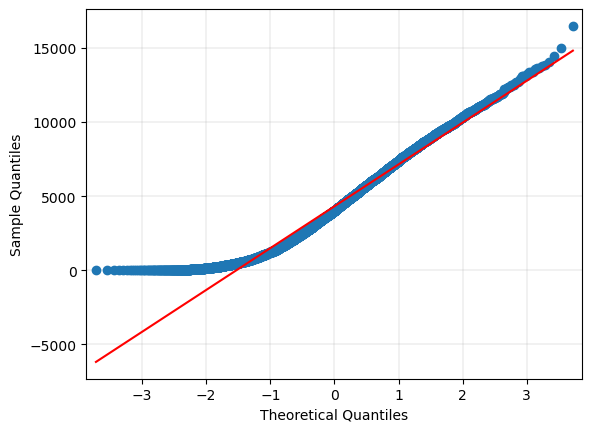

In [62]:
# 'Tool_Torque' QQ plot
qqplot(PM_df['Tool_Torque'], line='s')
plt.grid(linewidth=0.25)
plt.show()

In [63]:
# 'Tool_Torque' Skewness & Kurtosis
print(f'Skewness: {skew(PM_df['Tool_Torque']).round(3)}')
print(f'Kurtosis: {kurtosis(PM_df['Tool_Torque']).round(3)}')

Skewness: 0.469
Kurtosis: -0.464


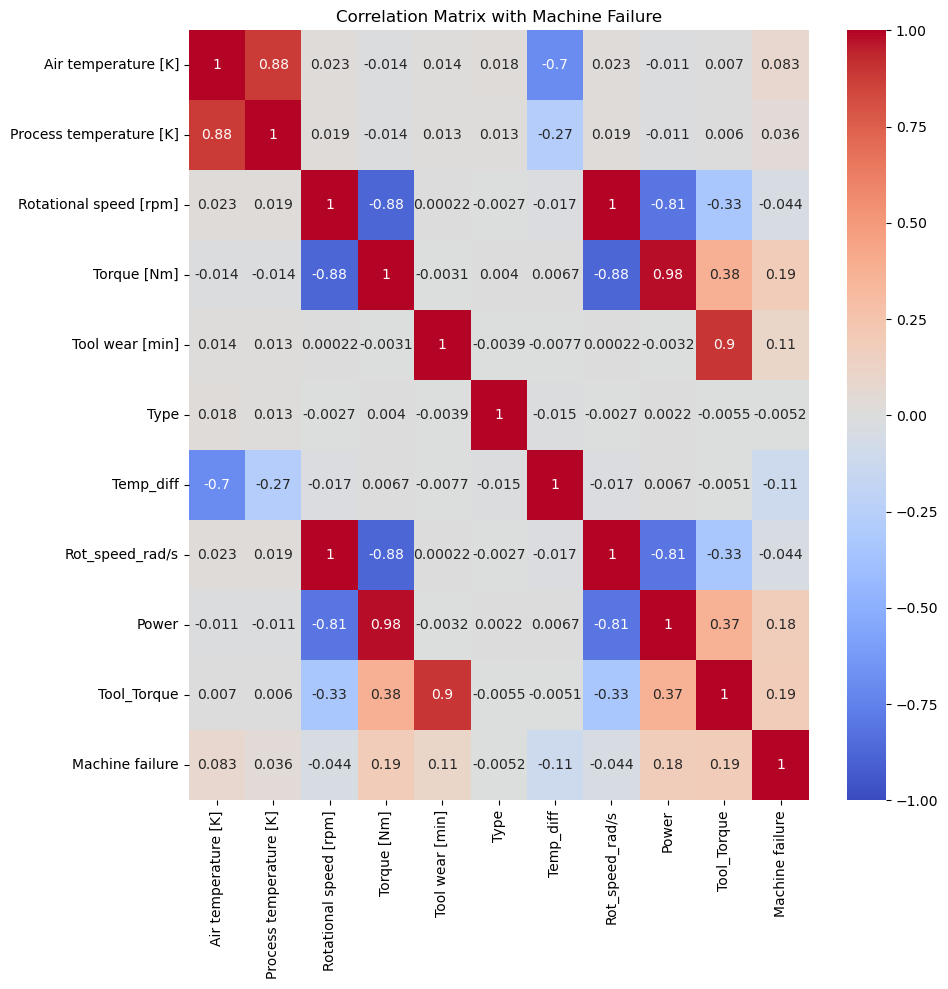

In [64]:
# Correlation with target
plt.figure(figsize=(10, 10))
correlation_matrix = PM_df[features + ['Machine failure']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix with Machine Failure')
plt.show()

In [66]:
# Generate desriptive statistics for required variables.
PM_df[['Tool wear [min]', 'Temp_diff', 'Rotational speed [rpm]', 'Power', 'Tool_Torque', 'Type', 'Machine failure']].describe().round(3)

,Tool wear [min],Temp_diff,Rotational speed [rpm],Power,Tool_Torque,Type,Machine failure
count,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000
mean,107.951,10.001,1538.776,6279.745,4314.665,1.199,0.034
std,63.654,1.001,179.284,1067.418,2826.568,0.600,0.181
min,0.000,7.600,1168.000,1148.441,0.000,0.000,0.000
25%,53.000,9.300,1423.000,5561.184,1963.650,1.000,0.000
50%,108.000,9.800,1503.000,6271.027,4012.950,1.000,0.000
75%,162.000,11.000,1612.000,7003.003,6279.000,2.000,0.000
max,253.000,12.100,2886.000,10469.923,16497.000,2.000,1.000
